In [1]:
import pandas as pd
from sklearn.impute import KNNImputer
from astral.sun import sun
from astral import LocationInfo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings("ignore", message=".*No supported index is available.*")
warnings.filterwarnings("ignore", message=".*has no associated frequency information.*")

# Loading the data

In [3]:
df = pd.read_csv("../data/imputed_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp', drop=True)

In [4]:
print(df.isnull().sum())

Wind_Dir_deg           0
Wind_Speed_ms          0
Humidity_pct           0
Outdoor_Temp_C         0
PV_Temperature         0
Solar_Radiation_Wm2    0
DC                     0
PM10_ugm3              0
PM25_ugm3              0
uv_index Index         0
Rain_mm                0
dew_point_2m (°C)      0
dtype: int64


# Splitting the data

--- Data Splitting Complete ---
Total number of data points: 7360
------------------------------
Training Set Shape:      (5152, 12)
Training Set Start Date: 2024-05-19 05:00:00
Training Set End Date:   2025-07-09 09:00:00
------------------------------
Test Set Shape:          (1471, 12)
Test Set Start Date:     2025-07-09 10:00:00
Test Set End Date:       2025-11-02 10:00:00
------------------------------
Validation Set Shape:    (737, 12)
Validation Set Start Date: 2025-11-02 11:00:00
Validation Set End Date:   2026-01-12 16:00:00


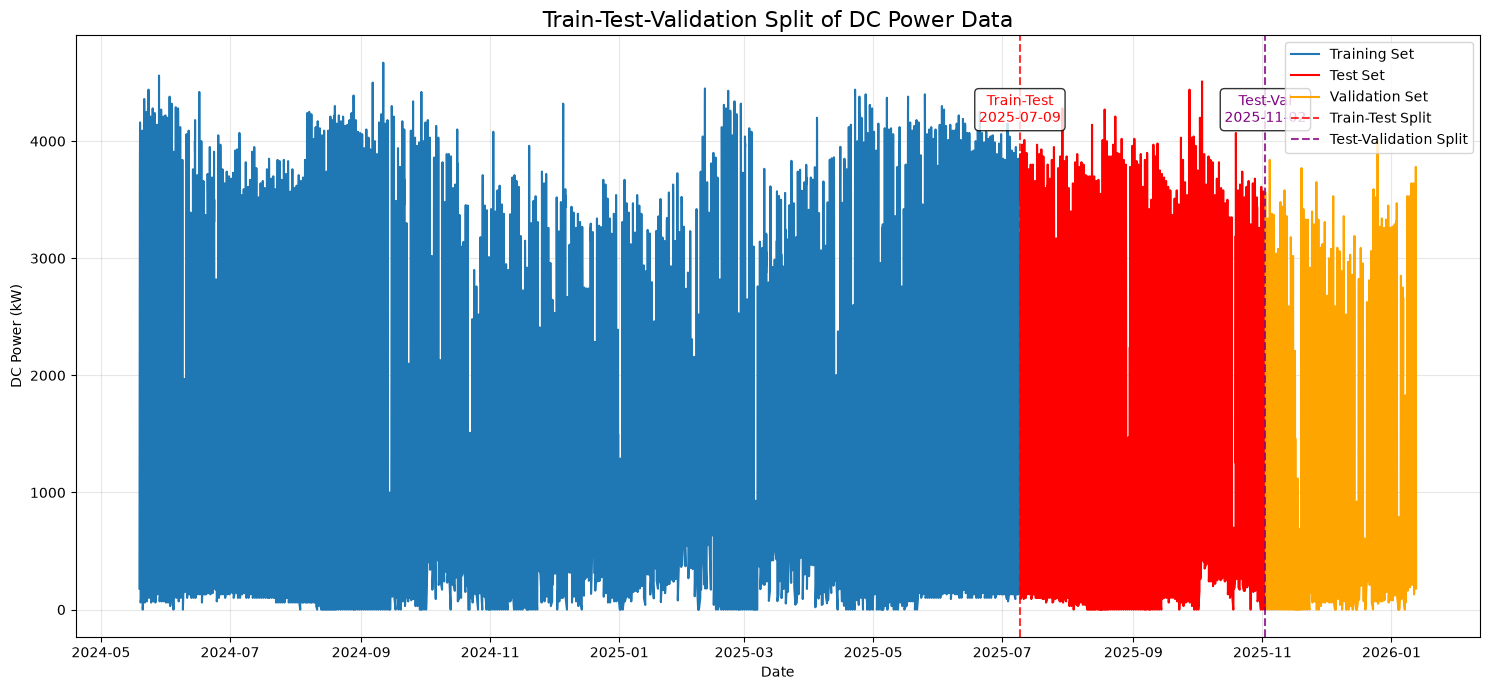

Length of train set: 5152
Length of test set: 1471
Length of validation set: 737

Actual split percentages:
Train: 70.0%
Test: 20.0%
Validation: 10.0%


In [5]:
import matplotlib.pyplot as plt

df.sort_index(inplace=True)

train_percent = 0.7
test_percent = 0.2

n_total = len(df)
train_end_index = int(n_total * train_percent)
test_end_index = int(n_total * (train_percent + test_percent))

train_df = df.iloc[:train_end_index]
test_df = df.iloc[train_end_index:test_end_index]
validation_df = df.iloc[test_end_index:]

print("--- Data Splitting Complete ---")
print(f"Total number of data points: {n_total}")
print("-" * 30)
print(f"Training Set Shape:      {train_df.shape}")
print(f"Training Set Start Date: {train_df.index.min()}")
print(f"Training Set End Date:   {train_df.index.max()}")
print("-" * 30)
print(f"Test Set Shape:          {test_df.shape}")
print(f"Test Set Start Date:     {test_df.index.min()}")
print(f"Test Set End Date:       {test_df.index.max()}")
print("-" * 30)
print(f"Validation Set Shape:    {validation_df.shape}")
print(f"Validation Set Start Date: {validation_df.index.min()}")
print(f"Validation Set End Date:   {validation_df.index.max()}")

split_time_1 = train_df.index.max()
split_time_2 = test_df.index.max()

plt.figure(figsize=(15, 7))

plt.plot(train_df.index, train_df['DC'], label='Training Set')
plt.plot(test_df.index, test_df['DC'], label='Test Set', color='red')
plt.plot(validation_df.index, validation_df['DC'], label='Validation Set', color='orange')

plt.axvline(x=split_time_1, color='red', linestyle='--', alpha=0.8, label='Train-Test Split')
plt.axvline(x=split_time_2, color='purple', linestyle='--', alpha=0.8, label='Test-Validation Split')

plt.text(split_time_1, plt.ylim()[1] * 0.9, f'Train-Test\n{split_time_1.strftime("%Y-%m-%d")}', 
         color='red', fontsize=10, ha='center', va='top', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.text(split_time_2, plt.ylim()[1] * 0.9, f'Test-Val\n{split_time_2.strftime("%Y-%m-%d")}', 
         color='purple', fontsize=10, ha='center', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title('Train-Test-Validation Split of DC Power Data', fontsize=16)
plt.xlabel('Date')
plt.ylabel('DC Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Length of train set: {len(train_df)}")
print(f"Length of test set: {len(test_df)}")
print(f"Length of validation set: {len(validation_df)}")

print(f"\nActual split percentages:")
print(f"Train: {len(train_df)/n_total:.1%}")
print(f"Test: {len(test_df)/n_total:.1%}")
print(f"Validation: {len(validation_df)/n_total:.1%}")

# Fitting an AR(p) model

# Choosing the right p

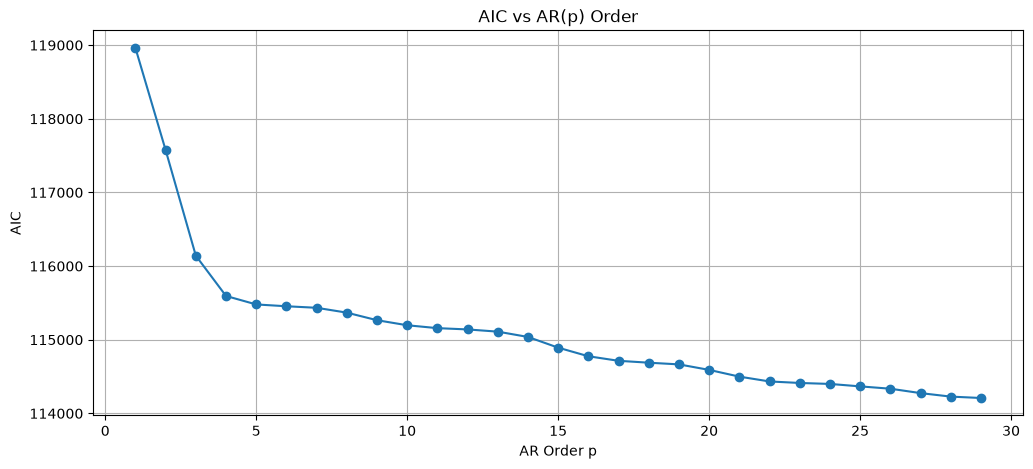

In [6]:
from statsmodels.tsa.ar_model import AutoReg
import pandas as pd
import matplotlib.pyplot as plt

ac_series = df['DC'].dropna().reset_index(drop=True)

aic_values = []
p_range = range(1, 30)

for p in p_range:
    try:
        model = AutoReg(ac_series, lags=p).fit()
        aic_values.append(model.aic)
    except Exception as e:
        print(f"p={p} failed: {e}")
        aic_values.append(None)

plt.figure(figsize=(12, 5))
plt.plot(p_range, aic_values, marker='o', linestyle='-')
plt.xlabel('AR Order p')
plt.ylabel('AIC')
plt.title('AIC vs AR(p) Order')
plt.grid(True)
plt.show()

## Fitting AR(15) model

In [7]:
from statsmodels.tsa.ar_model import AutoReg

train_series = train_df['DC'].dropna().reset_index(drop=True)
model = AutoReg(train_series, lags=15).fit()

print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:                     DC   No. Observations:                 5137
Model:                    AutoReg(15)   Log Likelihood              -40107.250
Method:               Conditional MLE   S.D. of innovations            595.014
Date:                Sun, 20 Sep 2026   AIC                          80248.501
Time:                        01:17:18   BIC                          80359.753
Sample:                            15   HQIC                         80287.440
                                 5152                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        571.7460     44.872     12.742      0.000     483.799     659.693
DC.L1          0.7851      0.014     56.696      0.000       0.758       0.812
DC.L2          0.0770      0.018      4.359      0.0

## Model Evaluation

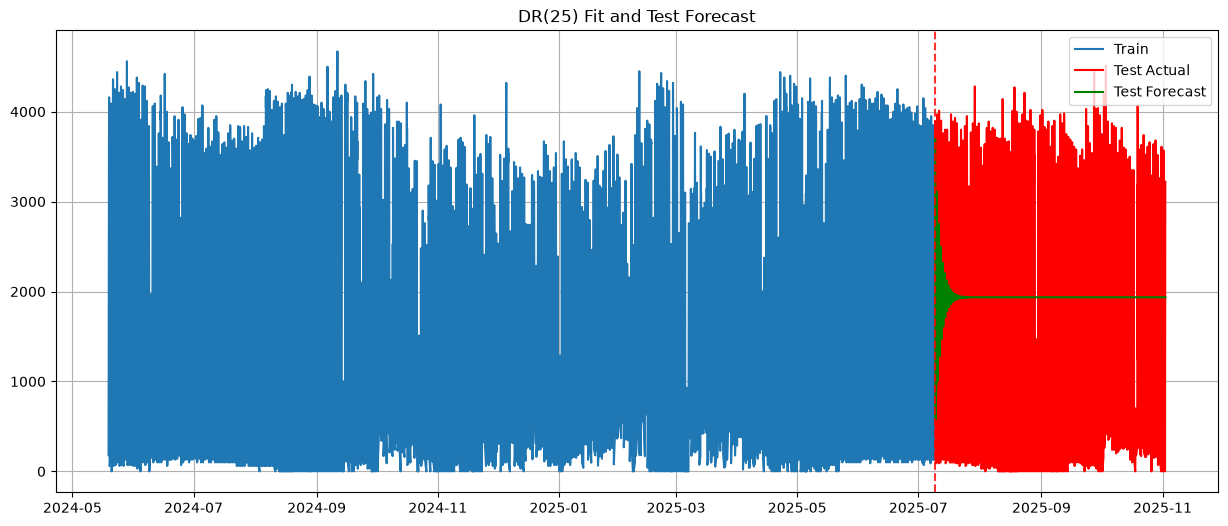

In [8]:
start = len(train_series)
end = start + len(test_df) - 1

pred_test = model.predict(start=start, end=end, dynamic=False)
pred_test.index = test_df.index

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test Actual', color='red')
plt.plot(pred_test.index, pred_test, label='Test Forecast', color='green')
plt.axvline(x=split_time_1, color='red', linestyle='--', alpha=0.8)
plt.title('DR(25) Fit and Test Forecast')
plt.legend()
plt.grid(True)
plt.show()

## Automatically choose best p

In [9]:
from statsmodels.tsa.ar_model import ar_select_order

# Automatically pick p using AIC
sel = ar_select_order(train_series.dropna(), maxlag=50, ic='aic', trend='c')

print("Best lag(s):", sel.ar_lags)

# Fit final model
final_model = sel.model.fit()
print(final_model.summary())


Best lag(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
                            AutoReg Model Results                             
Dep. Variable:                     DC   No. Observations:                 5102
Model:                    AutoReg(50)   Log Likelihood              -39597.443
Method:               Conditional MLE   S.D. of innovations            568.057
Date:                Sun, 20 Sep 2026   AIC                          79298.886
Time:                        01:17:27   BIC                          79638.830
Sample:                            50   HQIC                         79417.909
                                 5152                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const

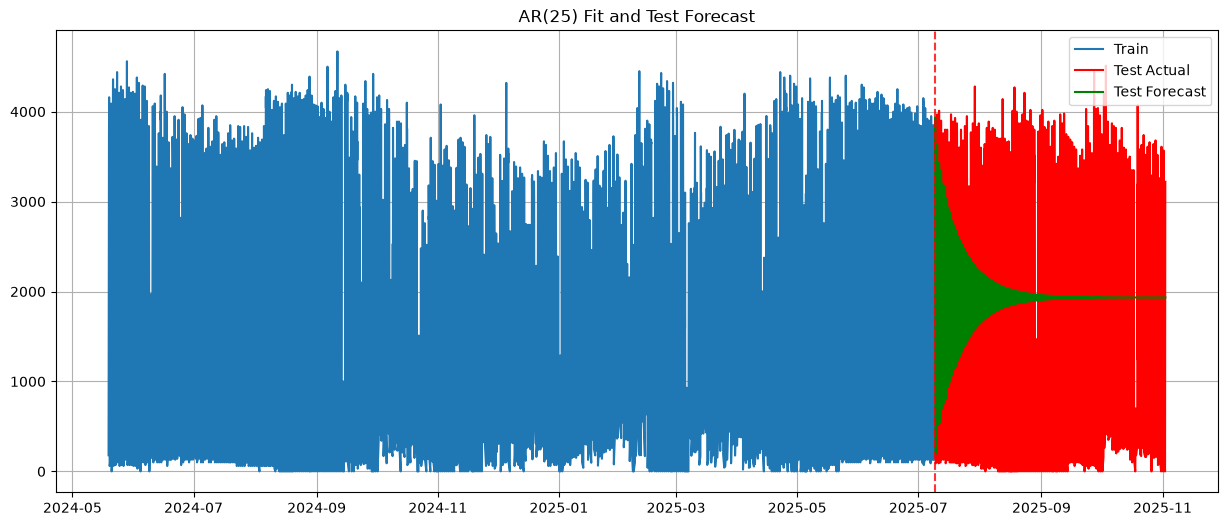

In [10]:
start = len(train_series)
end = start + len(test_df) - 1

pred_test = final_model.predict(start=start, end=end, dynamic=False)
pred_test.index = test_df.index

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test Actual', color='red')
plt.plot(pred_test.index, pred_test, label='Test Forecast', color='green')
plt.axvline(x=split_time_1, color='red', linestyle='--', alpha=0.8)
plt.title('AR(25) Fit and Test Forecast')
plt.legend()
plt.grid(True)
plt.show()

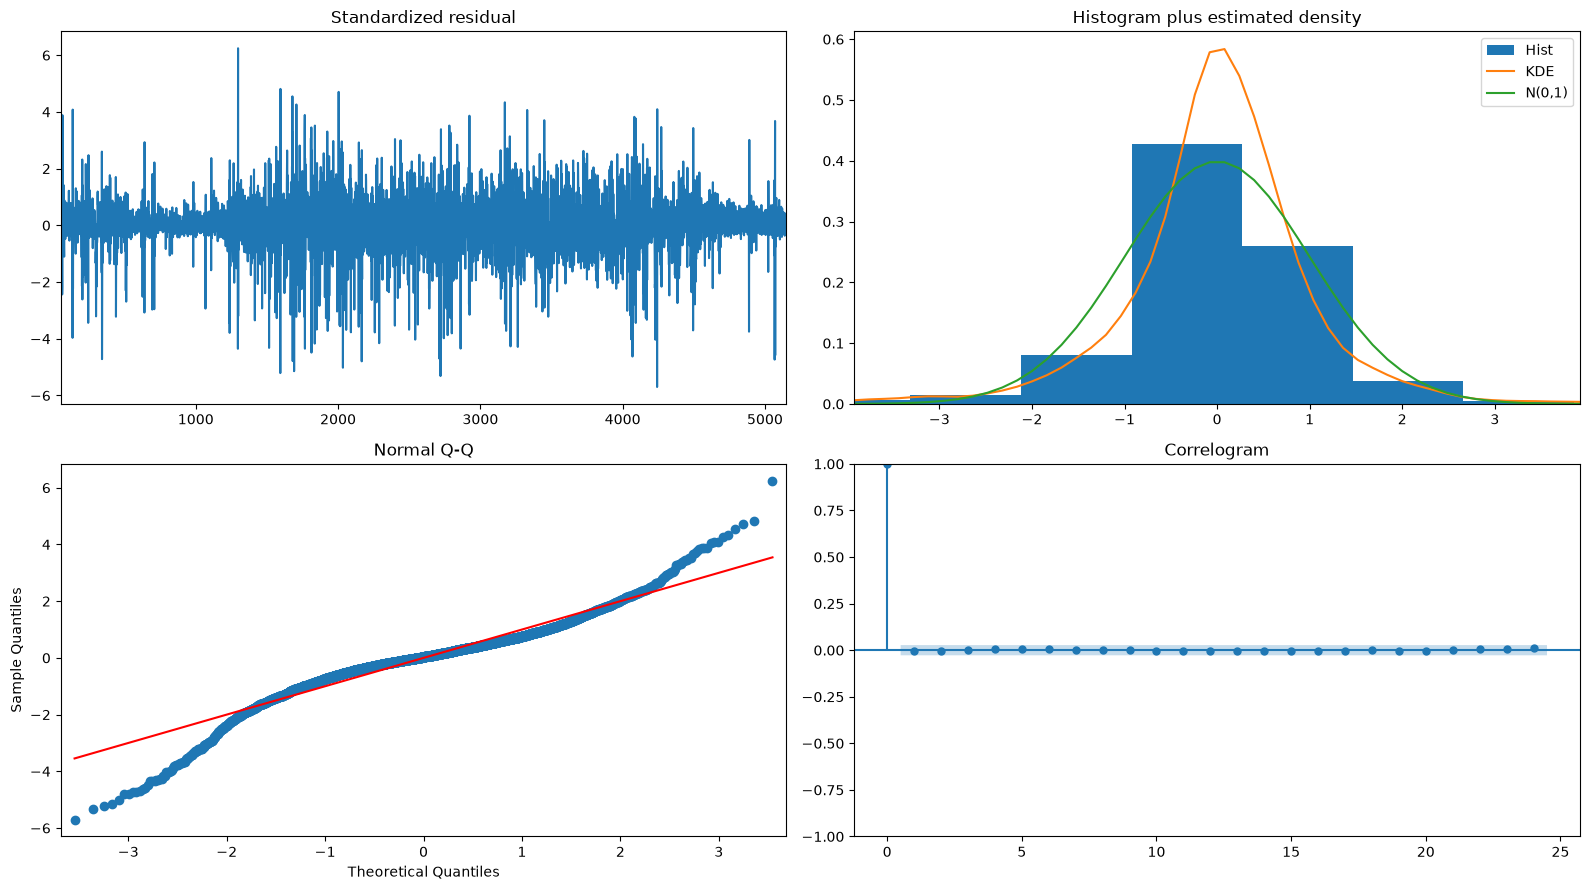

In [11]:
fig = plt.figure(figsize=(16, 9))
fig = final_model.plot_diagnostics(fig=fig, lags=24)
plt.tight_layout()
plt.show()

In [12]:
testing = pd.concat([train_df['DC'], test_df['DC']]).reset_index(drop=True)
ar_predictions = []

for i in range(len(train_df), len(train_df) + len(test_df)):
    updated_res = final_model.apply(testing[:i])
    ar_predictions.append(updated_res.forecast(1).iloc[0])

<Axes: xlabel='Timestamp'>

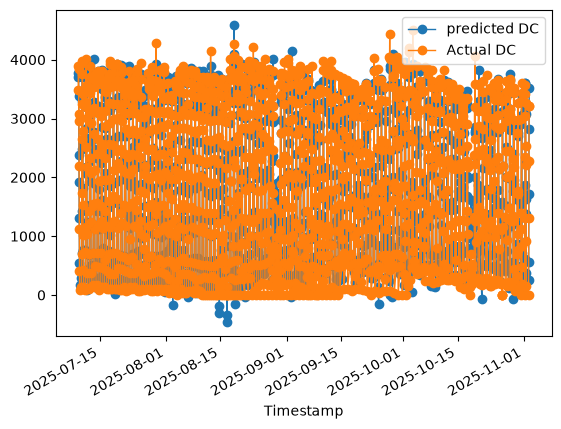

In [13]:
predictions = pd.DataFrame({
    "predicted DC": ar_predictions,
    "Actual DC": test_df['DC'],
})

# Plotting with the index of 'test' as the x-axis
_, ax = plt.subplots()
predictions.plot(ax=ax, marker='o', linestyle='-', linewidth=1)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Compute and print the evaluation metrics
mse = mean_squared_error(predictions['predicted DC'], predictions['Actual DC'])
print('Test MSE: %.5f' % mse)

rmse = np.mean(np.abs((predictions['Actual DC']- predictions['predicted DC'])/(predictions['Actual DC']+1)))
print('Test RMSE: %.3f' % rmse)

mae = mean_absolute_error(predictions['predicted DC'], predictions['Actual DC'])
print('Test MAE: %.3f' % mae)

r2 = r2_score(predictions['Actual DC'], predictions['predicted DC'])
print(f'R²: {r2:.3f}')

Test MSE: 329433.84884
Test RMSE: 14.977
Test MAE: 375.547
R²: 0.814


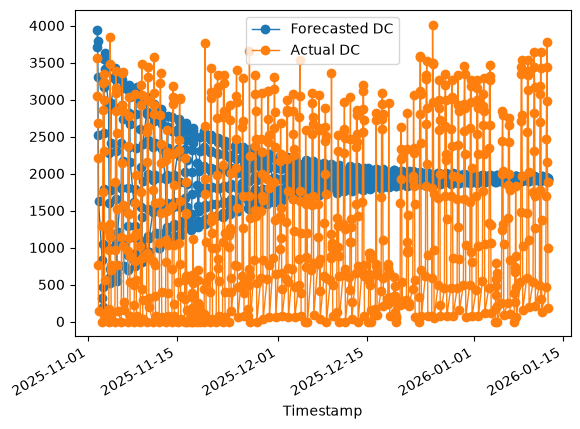

In [19]:
forecast_values = final_model.forecast(validation_df['DC'].size)
forecast_values.index = pd.to_datetime(validation_df['DC'].index)
validation_df['DC'].index = pd.to_datetime(validation_df['DC'].index)

predictions = pd.DataFrame({
    "Forecasted DC": forecast_values,
    "Actual DC": validation_df['DC'],
})

_, ax = plt.subplots()
ax = predictions.plot(ax=ax, marker='o', linestyle='-',linewidth=1)

### Save the AR model

In [20]:
import os

os.makedirs("../models", exist_ok=True)
final_model.save("../models/ar_model.pkl")
print("Saved AR model to ../models/ar_model.pkl")

Saved AR model to ../models/ar_model.pkl
